In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm
from imblearn.over_sampling import SMOTE

# Classification models used
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA

import warnings
warnings.filterwarnings('ignore')
!pip install shap
import shap

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
taiwanese_bankruptcy_prediction = fetch_ucirepo(id=572)
X = taiwanese_bankruptcy_prediction.data.features
y = taiwanese_bankruptcy_prediction.data.targets

y.value_counts()
# Size of minority class (bankrupt)
220/len(y)

0.03226279513125092

In [ ]:
skew_thresh = 1

numeric_cols = X.select_dtypes(include=[np.number])
skewness = numeric_cols.skew().sort_values(ascending=False)
skewed_cols = skewness[skewness > skew_thresh].index.tolist()

print(f"Applying log1p to {len(skewed_cols)} skewed features: {skewed_cols}")
X[skewed_cols] = X[skewed_cols].apply(np.log1p)

Applying log1p to 61 skewed features: [' Fixed Assets to Assets', ' Current Ratio', ' Total income/Total expense', ' Net Value Growth Rate', ' Contingent liabilities/Net worth', ' Realized Sales Gross Profit Growth Rate', ' Continuous Net Profit Growth Rate', ' Total Asset Return Growth Rate Ratio', ' Revenue per person', ' Quick Assets/Current Liability', ' Total debt/Total net worth', ' Degree of Financial Leverage (DFL)', ' Inventory/Working Capital', ' Revenue Per Share (Yuan ¥)', ' Non-industry income and expenditure/revenue', ' Equity to Long-term Liability', ' Quick Ratio', ' Average Collection Days', ' Liability-Assets Flag', ' Allocation rate per person', ' Liability to Equity', ' Accounts Receivable Turnover', ' Long-term fund suitability ratio (A)', ' Current Liability to Equity', ' Current Liabilities/Equity', ' Total assets to GNP price', ' Borrowing dependency', ' Cash Flow to Equity', ' Cash/Current Liability', ' Current Liability to Current Assets', ' Inventory and acco

In [ ]:
from tabulate import tabulate

corr_pairs = pd.DataFrame(columns=['Feature1', 'Feature2', 'Correlation'])
corr_matrix = X.corr()
threshold = 0.9

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            corr_pairs = pd.concat([corr_pairs, pd.DataFrame({'Feature1': [corr_matrix.columns[i]],
                                                              'Feature2': [corr_matrix.columns[j]],
                                                              'Correlation': [corr_matrix.iloc[i, j]]})],
                                  ignore_index=True)

feature_index = {feature: idx for idx, feature in enumerate(X.columns)}

corr_pairs['Feature1_Index'] = corr_pairs['Feature1'].map(feature_index)
corr_pairs['Feature2_Index'] = corr_pairs['Feature2'].map(feature_index)

high_corr_pairs = corr_pairs[(corr_pairs['Feature1'] != corr_pairs['Feature2']) &
                              (corr_pairs['Correlation'] >= threshold)].sort_values(by='Correlation', ascending=False)

high_corr_pairs_display = high_corr_pairs[['Feature1_Index', 'Feature1', 'Feature2_Index', 'Feature2', 'Correlation']]

print(tabulate(high_corr_pairs_display, headers='keys', tablefmt='pretty'))

+----+----------------+---------------------------------------------------------+----------------+---------------------------------------------------+--------------------+
|    | Feature1_Index |                        Feature1                         | Feature2_Index |                     Feature2                      |    Correlation     |
+----+----------------+---------------------------------------------------------+----------------+---------------------------------------------------+--------------------+
| 24 |       65       |               Current Liabilities/Equity                |       77       |            Current Liability to Equity            |        1.0         |
| 23 |       63       |              Current Liabilities/Liability              |       76       |          Current Liability to Liability           |        1.0         |
| 6  |       3        |                 Operating Gross Margin                  |       88       |               Gross Profit to Sales      

In [ ]:
# Dropped features with p>0.9
columns_to_drop = [65,88,17,4,15,41,26,9,7,0,90,22,1,85,18,42,39,72,5,85]

column_names_to_drop = X.columns[columns_to_drop]

X.drop(columns=column_names_to_drop, axis=1, inplace=True)

X.head()

,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Pre-tax net Interest Rate,Non-industry income and expenditure/revenue,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (A),...,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Total assets to GNP price,No-credit Interval,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0.405750,0.601457,0.796887,0.264398,0.000126,0.000000,0.377164,0.000725,0.0,0.137978,...,0.272242,0.111765,0.0,0.009177,0.622879,0.827890,0.026253,0.564050,1,0.016335
1,0.516730,0.610235,0.797380,0.265096,0.000290,0.000000,0.379715,0.000647,0.0,0.167420,...,0.273200,0.046669,0.0,0.008289,0.623652,0.839969,0.234738,0.570175,1,0.020581
2,0.472295,0.601450,0.796403,0.263929,0.000236,17.054189,0.377423,0.000790,0.0,0.163742,...,0.273468,0.025031,0.0,0.039223,0.623841,0.836774,0.026208,0.563706,1,0.016340
3,0.457733,0.583541,0.796967,0.264938,0.000108,0.000000,0.382337,0.000449,0.0,0.143396,...,0.264195,0.065085,0.0,0.003247,0.622929,0.834697,0.026346,0.564663,1,0.023699
4,0.522298,0.598783,0.797366,0.265034,22.788862,0.000000,0.380316,0.000686,0.0,0.154867,...,0.271223,0.046622,0.0,0.003870,0.623521,0.839973,0.024450,0.575617,1,0.034875


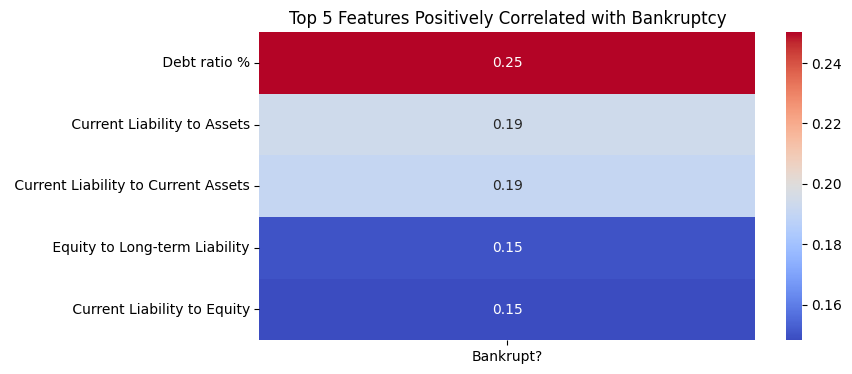

In [ ]:
sns.set_palette("pastel")

plt.figure(figsize=(8,4))
data2=pd.concat([y,X],axis=1)

correlations = data2.corr()['Bankrupt?'].sort_values(ascending=False)

# Select top 15 features
top_15_features = correlations[1:6]  # Exclude 'income' itself

top_15_corr_df = pd.DataFrame(top_15_features)
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 5 Features Positively Correlated with Bankruptcy')
plt.show()

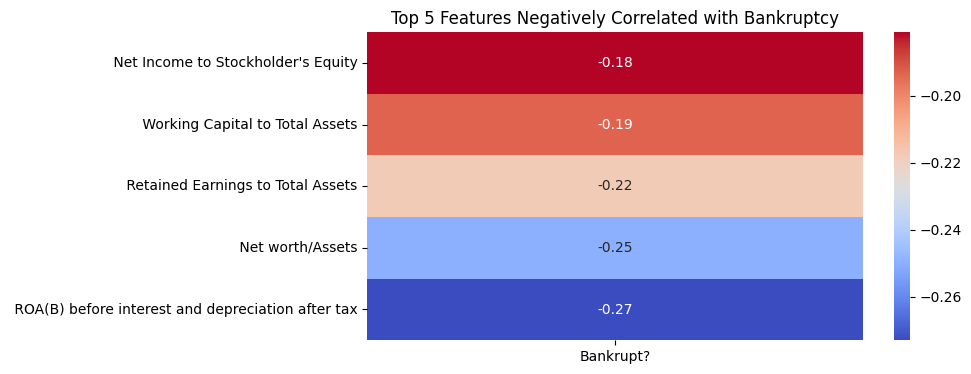

In [ ]:
plt.figure(figsize=(8,4))
top_15_corr_df = pd.DataFrame(correlations[71:76])
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 5 Features Negatively Correlated with Bankruptcy')
plt.show()

In [ ]:
scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=162)
X_train.head()

,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Pre-tax net Interest Rate,Non-industry income and expenditure/revenue,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (A),...,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Total assets to GNP price,No-credit Interval,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
4184,-1.078264,-0.563795,0.009532,-0.017720,1.464551,0.949403,0.061832,-0.182213,-0.890455,-0.675021,...,0.028583,-0.036089,-0.034272,-0.057462,-0.012429,-0.247503,-0.065701,-0.068574,0.0,-0.523264
4233,0.946170,0.434702,0.036172,-0.001488,-0.708161,-1.198089,1.094588,-0.182331,-0.207114,-0.061575,...,0.034067,-0.872801,-0.034272,-0.059582,0.054191,0.182859,-0.054965,-0.015101,0.0,0.879828
2322,0.120403,-0.006237,0.020648,-0.019136,-0.708165,-1.198099,-0.715428,-0.182229,-0.165519,-0.652121,...,0.048442,0.288747,-0.034272,-0.059744,-0.108517,0.072560,-0.043208,0.030166,0.0,-0.688314
1267,-0.023020,-0.541663,0.019282,0.002588,1.461565,-1.198099,0.042198,-0.182123,0.456221,-0.386424,...,-0.070123,0.116193,-0.034272,-0.059952,-0.008325,0.057998,-0.024094,0.084540,0.0,-0.380538
4566,-0.302912,0.379798,0.015165,-0.006956,-0.708144,-1.198087,-0.188791,-0.182213,-0.890455,-0.536485,...,0.159622,1.412913,-0.034272,-0.060059,-0.040519,-0.020542,0.635541,0.323601,0.0,-0.490849


In [ ]:
from imblearn.combine import SMOTETomek

def print_class_proportions(y, label=""):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    proportions = {cls: round(cnt / total, 3) for cls, cnt in zip(unique, counts)}
    print(f"{label} class proportions:", proportions)

# Before resampling
print_class_proportions(y_train, label="Before")

# Apply SMOTE-Tomek
smt = SMOTETomek(sampling_strategy=0.3, random_state=42)
X_train, y_train = smt.fit_resample(X_train, y_train)

# After resampling
print_class_proportions(y_train, label="After")

Before class proportions: {np.int64(0): np.float64(0.968), np.int64(1): np.float64(0.032)}
After class proportions: {np.int64(0): np.float64(0.77), np.int64(1): np.float64(0.23)}


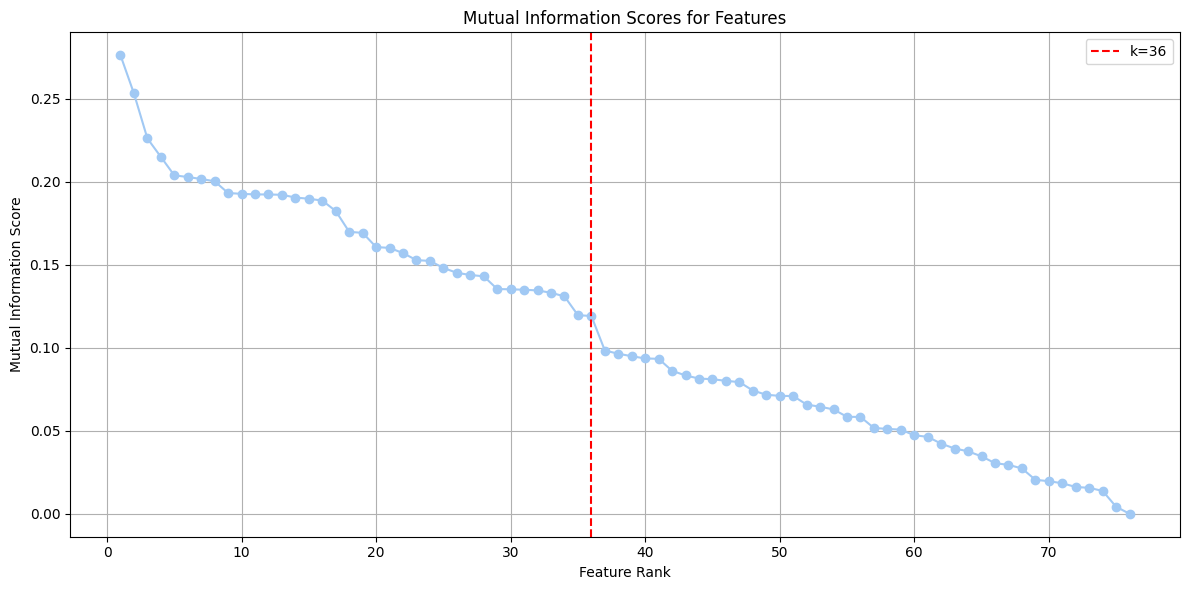

In [ ]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Get mutual information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(mi_series)+1), mi_series.values, marker='o')
plt.title("Mutual Information Scores for Features")
plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information Score")
plt.grid(True)

plt.axvline(x=36, color='red', linestyle='--', label='k=36')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
k =36
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
print("Top-k selected features:")
print(selected_features.tolist())

Top-k selected features:
[' ROA(B) before interest and depreciation after tax', ' Pre-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Research and development expense rate', ' Interest-bearing debt interest rate', ' Net Value Per Share (A)', ' Cash Flow Per Share', ' Operating Profit Per Share (Yuan ¥)', ' Total Asset Growth Rate', ' Net Value Growth Rate', ' Current Ratio', ' Quick Ratio', ' Interest Expense Ratio', ' Total debt/Total net worth', ' Debt ratio %', ' Net worth/Assets', ' Total Asset Turnover', ' Accounts Receivable Turnover', ' Inventory Turnover Rate (times)', ' Fixed Assets Turnover Frequency', ' Net Worth Turnover Rate (times)', ' Operating profit per person', ' Working Capital to Total Assets', ' Quick Assets/Current Liability', ' Cash/Current Liability', ' Inventory/Working Capital', ' Working Capital/Equity', ' Retained Earnings to Total Assets', ' Total income/Total expense', ' Cash Turnover Rate', ' Current Liability to Equity', ' Curre

In [ ]:
X_train=pd.DataFrame(X_train_selected, columns=selected_features)
X_test=pd.DataFrame(X_test_selected, columns=selected_features)

X_train.head()

,ROA(B) before interest and depreciation after tax,Pre-tax net Interest Rate,Non-industry income and expenditure/revenue,Research and development expense rate,Interest-bearing debt interest rate,Net Value Per Share (A),Cash Flow Per Share,Operating Profit Per Share (Yuan ¥),Total Asset Growth Rate,Net Value Growth Rate,...,Working Capital/Equity,Retained Earnings to Total Assets,Total income/Total expense,Cash Turnover Rate,Current Liability to Equity,Current Liability to Current Assets,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,-1.078264,0.009532,-0.017720,0.949403,-0.182213,-0.675021,0.585643,-0.526466,-0.351370,-0.017696,...,0.254518,-0.560925,-0.045306,-0.041511,0.245207,-0.036089,-0.247503,-0.065701,-0.068574,-0.523264
1,0.946170,0.036172,-0.001488,-1.198089,-0.182331,-0.061575,0.412289,0.430411,0.321623,-0.017624,...,0.455313,0.612530,0.014549,-0.841264,-0.310417,-0.872801,0.182859,-0.054965,-0.015101,0.879828
2,0.120403,0.020648,-0.019136,-1.198099,-0.182229,-0.652121,-1.934689,0.173551,-1.900979,-0.017529,...,0.128211,-0.159790,-0.023370,-0.031302,0.867662,0.288747,0.072560,-0.043208,0.030166,-0.688314
3,-0.023020,0.019282,0.002588,-1.198099,-0.182123,-0.386424,0.313056,-0.456267,0.376843,-0.017557,...,-0.082791,0.216585,-0.021041,-0.675188,-0.004223,0.116193,0.057998,-0.024094,0.084540,-0.380538
4,-0.302912,0.015165,-0.006956,-1.198087,-0.182213,-0.536485,-0.031105,-0.504117,0.363038,-0.017646,...,-0.569434,-0.027248,-0.032112,-0.841264,0.102037,1.412913,-0.020542,0.635541,0.323601,-0.490849


In [ ]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns)

corr_series = X_train.copy()
corr_series['Target'] = y_train.values
corr_to_target = corr_series.corr()['Target'].drop('Target')

feature_table = pd.DataFrame({
    'Feature': X_train.columns,
    'Mutual_Info_Score': mi_series.round(3),
    'Correlation_with_Target': corr_to_target.round(3)
})

feature_table_sorted = feature_table.sort_values(by='Mutual_Info_Score', ascending=False).reset_index(drop=True)

print(tabulate(feature_table_sorted, headers='keys', tablefmt='pretty', showindex=False))

+----------------------------------------------------+-------------------+-------------------------+
|                      Feature                       | Mutual_Info_Score | Correlation_with_Target |
+----------------------------------------------------+-------------------+-------------------------+
|                Total Asset Turnover                |       0.278       |         -0.184          |
|        Operating Profit Per Share (Yuan ¥)         |       0.252       |         -0.378          |
|              Total Asset Growth Rate               |       0.224       |         -0.086          |
|         Net Income to Stockholder's Equity         |       0.215       |         -0.168          |
|              Net Value Per Share (A)               |       0.204       |         -0.404          |
|         Retained Earnings to Total Assets          |       0.203       |         -0.471          |
|       Research and development expense rate        |       0.203       |          0.029  

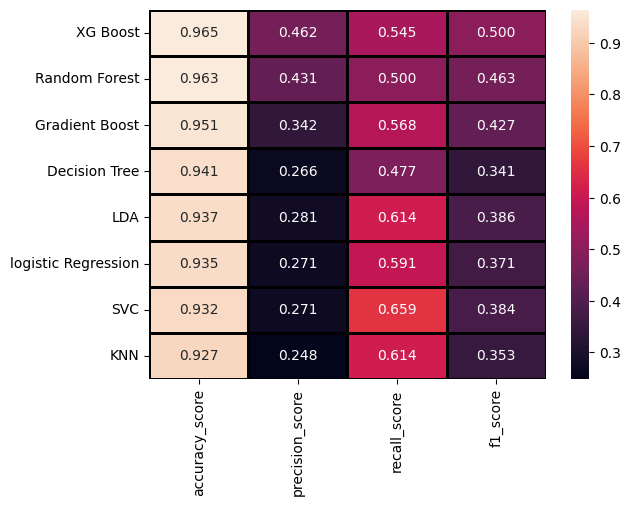

In [ ]:
model_dic={
    'logistic Regression':LogisticRegression(),
    'LDA':LDA(),
    'Random Forest':RandomForestClassifier(n_estimators=100,random_state=168),
    "Decision Tree":DTC(),
    'Gradient Boost':GradientBoostingClassifier(random_state=168),
    'XG Boost':XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=168),
    "KNN":KNeighborsClassifier(),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)
        y_pred = model.predict(X_test.to_numpy())
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc_dic[i]={'accuracy_score':accuracy_score(y_test,y_pred), # Removed the extra space after accuracy_score
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score'],ascending=False) # Now this line should work

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1, fmt=".3f")
plt.show()

In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())


Bankrupt?
0            5276
1            1580
Name: count, dtype: int64
Bankrupt?
0            1320
1              44
Name: count, dtype: int64


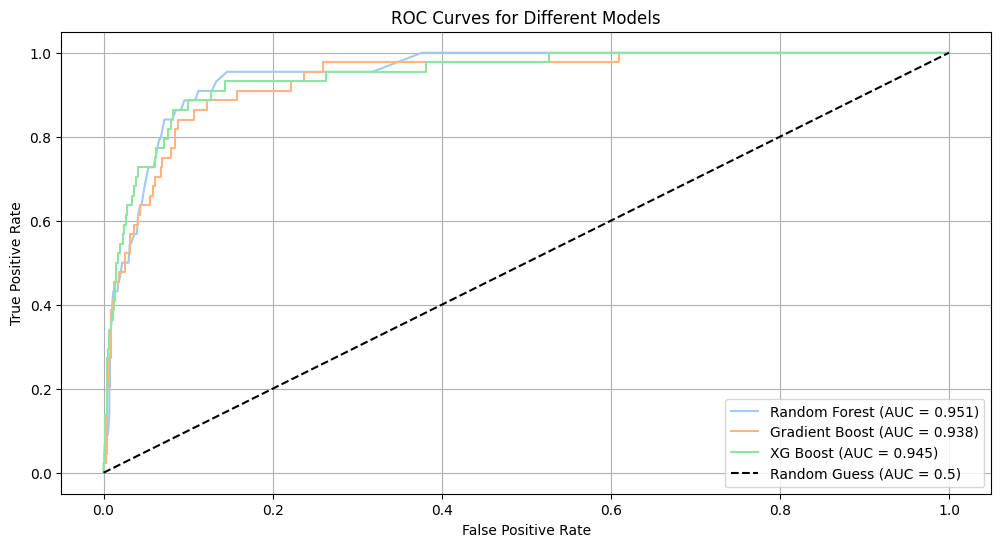

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
plt.figure(figsize=(12,6))

model_dic={
    'Random Forest':RandomForestClassifier(n_estimators=100,random_state=168),
    'Gradient Boost':GradientBoostingClassifier(random_state=168),
    'XG Boost':XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=168),
}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)
        y_score = model.predict_proba(X_test.to_numpy())[:, 1]

    else:
        model.fit(X_train,y_train)
        y_score=model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
def tune_threshold_f1(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 100)
    f1_scores = [f1_score(y_test, y_proba > t) for t in thresholds]

    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]

    print(f"🔍 {name}: Best Threshold = {best_threshold:.3f}, Best F1 Score = {best_f1:.3f}")

    # Optional: plot
    plt.plot(thresholds, f1_scores, label=name)

    return {
        "model": name,
        "best_threshold": best_threshold,
        "best_f1": best_f1,
        "model_object": model,
    }


🔍 Random Forest: Best Threshold = 0.585, Best F1 Score = 0.487
🔍 XGBoost: Best Threshold = 0.577, Best F1 Score = 0.516
🔍 Gradient Boost: Best Threshold = 0.698, Best F1 Score = 0.494


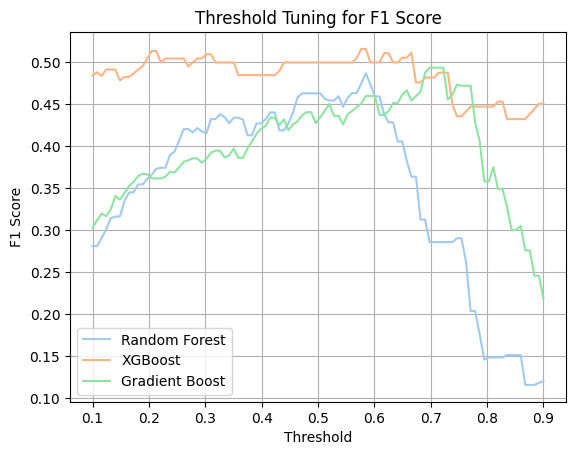

In [ ]:
results = []

# Random Forest
rf = RandomForestClassifier(n_estimators=100,random_state=168)
results.append(tune_threshold_f1(rf, X_train, y_train, X_test, y_test, "Random Forest"))

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=168)
results.append(tune_threshold_f1(xgb, X_train, y_train, X_test, y_test, "XGBoost"))

# Grad Boost
dt = GradientBoostingClassifier(random_state=168)
results.append(tune_threshold_f1(dt, X_train, y_train, X_test, y_test, "Gradient Boost"))

# Show threshold vs. F1 plots
plt.title("Threshold Tuning for F1 Score")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()